# Single LSTM model, Training and evaluation

In [1]:
y = 0
y

0

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import rpy2.robjects as robjects

folder_name = '3_state_model'
n_states = 3

data_log = pd.read_csv(folder_name + "/close_data_log.csv")

# Helper function to convert R data.frame to pandas DataFrame
def r_to_df(r_df):
    return pd.DataFrame({name: np.array(r_df.rx2(name)) for name in r_df.names})

# Read the RDS files using rpy2
readRDS = robjects.r['readRDS']

hmm_stats_r = readRDS(folder_name + "/hmm_stats_df.rds")
hmm_stats_df = r_to_df(hmm_stats_r)

hmm_state_losses = np.array(readRDS(folder_name + "/hmm_state_losses.rds"))
hmm_predictions = np.array(readRDS(folder_name + "/hmm_predictions.rds"))
hmm_ground_truth = np.array(readRDS(folder_name + "/hmm_ground_truth.rds"))
hmm_valid_loss = np.array(readRDS(folder_name + "/hmm_valid_loss.rds"))
hmm_transition_matrix = pd.read_csv(folder_name + "/transition_matrix.csv")

X_train_orig = np.array(readRDS(folder_name + "/lstm_X_train.rds"))
Y_train_orig = np.array(readRDS(folder_name + "/lstm_Y_train.rds"))
X_valid_orig = np.array(readRDS(folder_name + "/lstm_X_valid.rds"))
Y_valid_orig = np.array(readRDS(folder_name + "/lstm_Y_valid.rds"))
X_test_orig = np.array(readRDS(folder_name + "/lstm_X_test.rds"))
Y_test_orig = np.array(readRDS(folder_name + "/lstm_Y_test.rds"))

last_state_test = X_test_orig[:, -1, :n_states]
last_state_valid = X_valid_orig[:, -1, :n_states]

n_states = Y_train_orig.shape[2]
X_train_orig.shape, Y_train_orig.shape, X_valid_orig.shape, Y_valid_orig.shape, X_test_orig.shape, Y_test_orig.shape

Install package `httpgd` to use vscode-R with httpgd!


FileNotFoundError: [Errno 2] No such file or directory: '3_state_model/close_data_log.csv'

In [4]:
forecast_horizon = Y_train_orig.shape[1]

# Create a function to prepare data for all splits
def prepare_data_with_horizon(X, Y, shuffle=True):

    # Create one-hot encoded horizon inputs
    horizon_input = np.eye(forecast_horizon)
    horizon_input = np.repeat(horizon_input, X.shape[0], axis=0)

    # Repeat X for each forecast horizon
    X = np.concatenate([X for i in range(forecast_horizon)], axis=0)
    # Get Y for each forecast horizon
    Y = np.concatenate([Y[:, i, :] for i in range(forecast_horizon)], axis=0)
    
    # Shuffle the rows of X, horizon_input, and Y in the same order using numpy
    if shuffle:
        idx = np.random.permutation(X.shape[0])
        X = X[idx]
        horizon_input = horizon_input[idx]
        Y = Y[idx]
    return X, horizon_input, Y

# Prepare validation and test data
X_train_full, horizon_train, Y_train = prepare_data_with_horizon(X_train_orig, Y_train_orig, shuffle=False)
X_valid_full, horizon_valid, Y_valid = prepare_data_with_horizon(X_valid_orig, Y_valid_orig, shuffle=False)
X_test_full, horizon_test, Y_test = prepare_data_with_horizon(X_test_orig, Y_test_orig, shuffle=False)

X_train_full.shape, horizon_train.shape, Y_train.shape, X_valid_full.shape, horizon_valid.shape, Y_valid.shape, X_test_full.shape, horizon_test.shape, Y_test.shape

((6720, 10, 20),
 (6720, 10),
 (6720, 3),
 (2340, 10, 20),
 (2340, 10),
 (2340, 3),
 (3090, 10, 20),
 (3090, 10),
 (3090, 3))

### Define the model

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt
from tensorflow.keras.losses import kullback_leibler_divergence
from tensorflow.keras.layers import Concatenate

# Assuming X_train, Y_train, X_valid, Y_valid, and n_states are defined elsewhere
# lookback and forecast_horizon are provided but not directly used in model building

# Compute Dirichlet parameters and predicted probabilities (for reference, not used in model)
def dirichlet_layer(evidence):
    alpha = evidence + 1
    S = tf.reduce_sum(alpha, axis=-1, keepdims=True)
    probs = alpha / S
    return probs, alpha, S

# Custom evidential loss with annealing
class EvidentialLoss(tf.keras.losses.Loss):
    def __init__(self, annealing_rate=100.0, name='evidential_loss'):
        super().__init__(name=name)
        self.annealing_rate = tf.constant(annealing_rate, dtype=tf.float32)
        self.current_epoch = tf.Variable(0.0, trainable=False, dtype=tf.float32)
    
    def call(self, y_true, evidence):
        alpha = evidence + 1
        S = tf.reduce_sum(alpha, axis=-1, keepdims=True)
        probs = alpha / S
        
        # Classification error: categorical cross-entropy for soft probability targets
        err = tf.keras.losses.categorical_crossentropy(y_true, probs)

        var = tf.reduce_sum(probs * (1 - probs) / (S + 1), axis=-1, keepdims=True)
        
        # Annealing factor for the regularization term
        lambda_ = tf.minimum(1.0, self.current_epoch / self.annealing_rate)
        
        return tf.reduce_mean(err + lambda_ * var, axis=-1)

# Custom callback to update the current epoch in the loss instance
class AnnealingCallback(tf.keras.callbacks.Callback):
    def on_epoch_begin(self, epoch, logs=None):
        if hasattr(self.model, 'loss') and isinstance(self.model.loss, EvidentialLoss):
            self.model.loss.current_epoch.assign(tf.cast(epoch, tf.float32))

# Custom metric using KL divergence
def evidential_kl_divergence(y_true, y_pred):
    probs, _, _ = dirichlet_layer(y_pred)  # Derive probabilities from evidence
    return kullback_leibler_divergence(y_true, probs)

2026-03-03 10:56:11.427082: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-03 10:56:11.442168: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772564171.457323 1541166 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772564171.461571 1541166 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772564171.475627 1541166 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [12]:
## Hyperparameters
lookback = 10
include_tsx = True
include_crude = False
include_gold = True
include_copper = True
include_sp500 = True

lstm_units = 8
dense_units = 8
dropout_rate = 0.3
embedding_dim = 4

feature_mask_list = (
    [1.0] * 4 if include_tsx else [0.0] * 4
) + (
    [1.0] * 4 if include_crude else [0.0] * 4
) + (
    [1.0] * 4 if include_gold else [0.0] * 4
) + (
    [1.0] * 4 if include_copper else [0.0] * 4
) + (
    [1.0] * 4 if include_sp500 else [0.0] * 4
)
feature_mask_list

[1.0,
 1.0,
 1.0,
 1.0,
 0.0,
 0.0,
 0.0,
 0.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0]

In [13]:
# Keep only the features marked as 1.0 in feature_mask_list
selected_cols = np.array(feature_mask_list, dtype=bool)

X_train = X_train_full[:, -lookback:, selected_cols]
X_valid = X_valid_full[:, -lookback:, selected_cols]
X_test = X_test_full[:, -lookback:, selected_cols]

print("Original shape:", X_train_full.shape)
print("Reduced shape :", X_train.shape)
print("Horizon Input shape:", horizon_train.shape)
print("Y_train shape:", Y_train.shape)

Original shape: (6720, 10, 20)
Reduced shape : (6720, 10, 16)
Horizon Input shape: (6720, 10)
Y_train shape: (6720, 3)


In [47]:
tf.keras.backend.clear_session()

# Primary input for timeseries data (adjust shape if X_train changes)
timeseries_input = layers.Input(shape=X_train.shape[1:])

# Auxiliary input for one-hot encoded horizon (length 10)
horizon_input = layers.Input(shape=(10,))

# Embed the horizon input into a dense representation
horizon_embed = layers.Dense(embedding_dim, activation='relu')(horizon_input)

# LSTM layer with added dropout
lstm_out = layers.SimpleRNN(lstm_units, dropout=dropout_rate)(timeseries_input)

# Concatenate LSTM output with embedded horizon
concat = Concatenate()([lstm_out, horizon_embed])

# Dense layers following concatenation
dense1 = layers.Dense(8, activation='relu')(concat)
drop1 = layers.Dropout(dropout_rate)(dense1)
dense2 = layers.Dense(4, activation='relu')(drop1)
drop2 = layers.Dropout(dropout_rate)(dense2)

# Output raw evidence (non-negative)
output = layers.Dense(n_states, activation='softplus')(drop2)

# Define the multi-input model
model = models.Model(inputs=[timeseries_input, horizon_input], outputs=output)

model.compile(
    loss=EvidentialLoss(annealing_rate=100.0),
    optimizer=Adam(learning_rate=0.0001),
    metrics=['accuracy', evidential_kl_divergence]  # Accuracy on argmax(probs)
)


In [48]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 10, 16)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn          │ (None, 8)         │        200 │ input_layer[0][0] │
│ (SimpleRNN)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 4)         │         44 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 12)        │          0 │ simple_rnn[0][0], │
│ (Concatenate)       │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 8)         │        104 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 8)         │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 4)         │         36 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 4)         │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 3)         │         15 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 399 (1.56 KB)

 Trainable params: 399 (1.56 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
import os
import random

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

os.environ['PYTHONHASHSEED'] = '0'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

X = np.append(X_train, X_valid, axis=0)
horizon = np.append(horizon_train, horizon_valid, axis=0)
Y = np.append(Y_train, Y_valid, axis=0)

history = model.fit(
    [X_train, horizon_train], Y_train,
    validation_data=([X_valid, horizon_valid], Y_valid),
    callbacks=[AnnealingCallback()],
    epochs=80,  # Use the same number as in your tuner setup
    verbose=1  # Set to 0 for silent output if preferred
)

Epoch 1/80
210/210 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.2854 - evidential_kl_divergence: 0.7568 - loss: 1.1163 - val_accuracy: 0.1231 - val_evidential_kl_divergence: 0.7681 - val_loss: 1.1093
Epoch 2/80
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3653 - evidential_kl_divergence: 0.7443 - loss: 1.1048 - val_accuracy: 0.4658 - val_evidential_kl_divergence: 0.7542 - val_loss: 1.0965
Epoch 3/80
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4307 - evidential_kl_divergence: 0.7359 - loss: 1.0976 - val_accuracy: 0.6654 - val_evidential_kl_divergence: 0.7404 - val_loss: 1.0839
Epoch 4/80
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4839 - evidential_kl_divergence: 0.7277 - loss: 1.0905 - val_accuracy: 0.7064 - val_evidential_kl_divergence: 0.7272 - val_loss: 1.0718
Epoch 5/80
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5116 - evidential_kl_divergence: 0.7199 - loss: 1.0838 - val_accuracy: 0.7068 - val_evidential_kl_divergence: 0.7135 - val_los

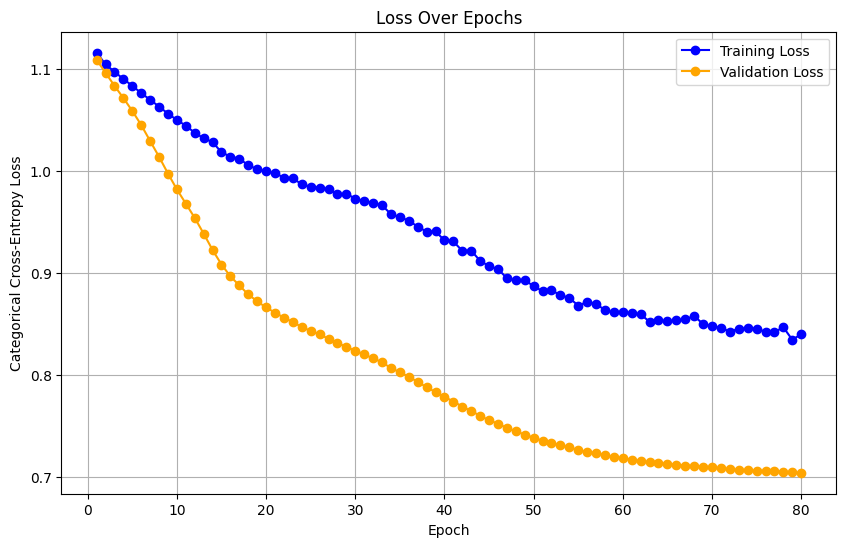

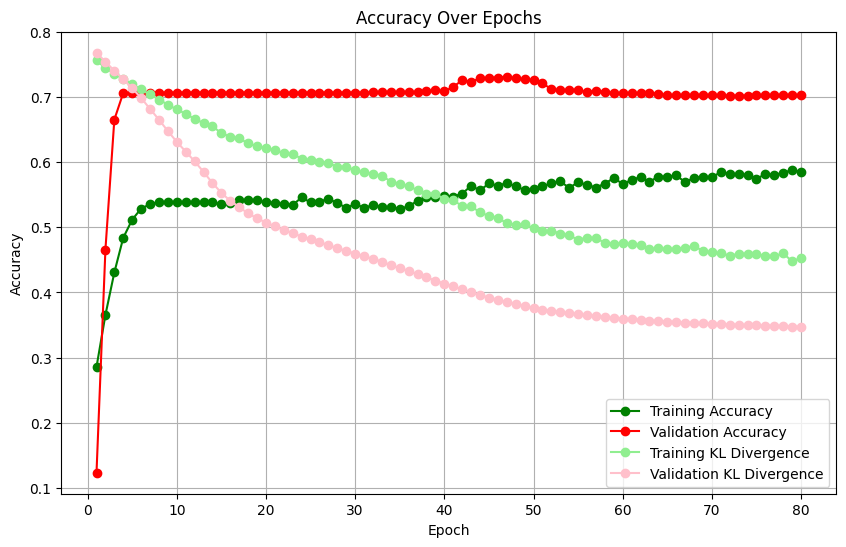

In [50]:
def plot_training_history(history):
    epochs = range(1, len(history.history['loss']) + 1)
    
    # Plot Loss
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, history.history['loss'], label='Training Loss', marker='o', color='blue')
    plt.plot(epochs, history.history['val_loss'], label='Validation Loss', marker='o', color='orange')
    plt.title('Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Categorical Cross-Entropy Loss')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Plot Accuracy
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, history.history['accuracy'], label='Training Accuracy', marker='o', color='green')
    plt.plot(epochs, history.history['val_accuracy'], label='Validation Accuracy', marker='o', color='red')
    plt.plot(epochs, history.history['evidential_kl_divergence'], label='Training KL Divergence', marker='o', color='lightgreen')
    plt.plot(epochs, history.history['val_evidential_kl_divergence'], label='Validation KL Divergence', marker='o', color='pink')
    plt.title('Accuracy Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()
    
plot_training_history(history)

# Get test statistics

In [51]:
# Validation predictions
def test_results(model, X, horizon, Y):
    Y_hat = model.predict([X, horizon])

    probs, alpha, S = dirichlet_layer(Y_hat)
    probs = probs.numpy()
    S = S.numpy()

    probs_reshaped = probs.reshape(forecast_horizon, -1, n_states).transpose(1, 0, 2)
    S_reshaped = S.reshape(forecast_horizon, -1).T

    Y_reshaped = Y.reshape(forecast_horizon, -1, n_states).transpose(1, 0, 2)

    loss = -np.sum(Y * np.log(np.clip(probs, 1e-15, 1.0)), axis=1)
    loss_reshaped = loss.reshape(forecast_horizon, -1).T

    stats = pd.DataFrame({
        'mean': np.nanmean(loss_reshaped, axis=0),
        'median': np.nanmedian(loss_reshaped, axis=0),
        'P25': np.nanpercentile(loss_reshaped, 25, axis=0),
        'P75': np.nanpercentile(loss_reshaped, 75, axis=0),
        'max': np.nanmax(loss_reshaped, axis=0),
        'min': np.nanmin(loss_reshaped, axis=0)
    })

    return probs_reshaped, S_reshaped, loss_reshaped, stats, Y_reshaped

probs_valid, S_valid, loss_valid, stats_valid, Y_valid_reshaped = test_results(model, X_valid, horizon_valid, Y_valid)
probs_test, S_test, loss_test, stats_test, Y_test_reshaped = test_results(model, X_test, horizon_test, Y_test)

stats_test

74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


,mean,median,P25,P75,max,min
0,0.758847,0.693580,0.553832,0.870485,3.149293,0.245935
1,0.779593,0.699559,0.564636,0.874540,3.303663,0.256716
2,0.803744,0.704360,0.571253,0.897386,3.715941,0.253676
3,0.819353,0.710644,0.573383,0.898857,3.705441,0.523160
4,0.837945,0.733211,0.584552,0.899028,3.698377,0.523602
5,0.852509,0.732777,0.587845,0.902537,3.729715,0.522271
6,0.864666,0.733155,0.592149,0.901412,3.702636,0.523529
7,0.870915,0.733702,0.593312,0.900531,3.710886,0.523729
8,0.874092,0.733632,0.596292,0.903223,3.711524,0.523113
9,0.877761,0.744505,0.598820,0.903314,3.700777,0.523973


In [52]:
hmm_stats_df

,Horizon,mean,median,P25,P75,max,min
0,1,0.657512,0.592399,0.329328,0.816298,5.625449,0.039909
1,2,0.727542,0.644027,0.408120,0.864884,5.529780,0.083007
2,3,0.775176,0.694416,0.459106,0.887598,5.615762,0.124812
3,4,0.807098,0.712133,0.524258,0.891424,5.198849,0.170251
4,5,0.829748,0.722985,0.561671,0.890272,4.871359,0.401844
5,6,0.843238,0.726313,0.591778,0.869435,4.607836,0.440607
6,7,0.853018,0.729690,0.613380,0.854625,4.383486,0.472610
7,8,0.860973,0.733079,0.626066,0.847388,4.197208,0.500517
8,9,0.863421,0.737364,0.636396,0.832350,4.042293,0.525266
9,10,0.864926,0.739618,0.644302,0.837054,3.907720,0.546330


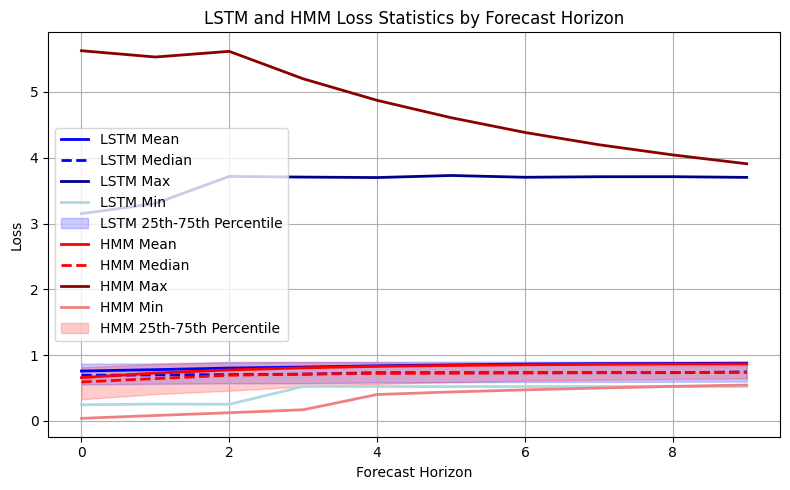

In [53]:
def plot_model_comparison(stats_df_1, stats_df_2, title_1, title_2, figsize=(8, 5)):

    fig, ax = plt.subplots(figsize=figsize)
    
    horizons = stats_df_1.index
    
    # Plot first model stats
    ax.plot(horizons, stats_df_1['mean'], label=f'{title_1} Mean', color='blue', linewidth=2)
    ax.plot(horizons, stats_df_1['median'], label=f'{title_1} Median', color='blue', linestyle='--', linewidth=2)
    ax.plot(horizons, stats_df_1['max'], label=f'{title_1} Max', color='darkblue', linewidth=2)
    ax.plot(horizons, stats_df_1['min'], label=f'{title_1} Min', color='lightblue', linewidth=2)
    ax.fill_between(horizons, stats_df_1['P25'], stats_df_1['P75'], color='blue', alpha=0.2, label=f'{title_1} 25th-75th Percentile')
    
    # Plot second model stats
    ax.plot(horizons, stats_df_2['mean'], label=f'{title_2} Mean', color='red', linewidth=2)
    ax.plot(horizons, stats_df_2['median'], label=f'{title_2} Median', color='red', linestyle='--', linewidth=2)
    ax.plot(horizons, stats_df_2['max'], label=f'{title_2} Max', color='darkred', linewidth=2)
    ax.plot(horizons, stats_df_2['min'], label=f'{title_2} Min', color='lightcoral', linewidth=2)
    ax.fill_between(horizons, stats_df_2['P25'], stats_df_2['P75'], color='red', alpha=0.2, label=f'{title_2} 25th-75th Percentile')
    
    ax.set_xlabel('Forecast Horizon')
    ax.set_ylabel('Loss')
    ax.set_title(f'{title_1} and {title_2} Loss Statistics by Forecast Horizon')
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

# Use the function
plot_model_comparison(stats_test, hmm_stats_df, 'LSTM', 'HMM')

In [54]:
argmax_states = np.argmax(probs_test, axis=2)
# Get value counts of the most likely states across all samples and horizons
state_counts = pd.Series(argmax_states.flatten()).value_counts()
state_counts

2    2538
1     435
0     117
Name: count, dtype: int64

In [55]:
pd.Series(np.argmax(Y_test, axis=1).flatten()).value_counts()

2    1970
1    1020
0     100
Name: count, dtype: int64

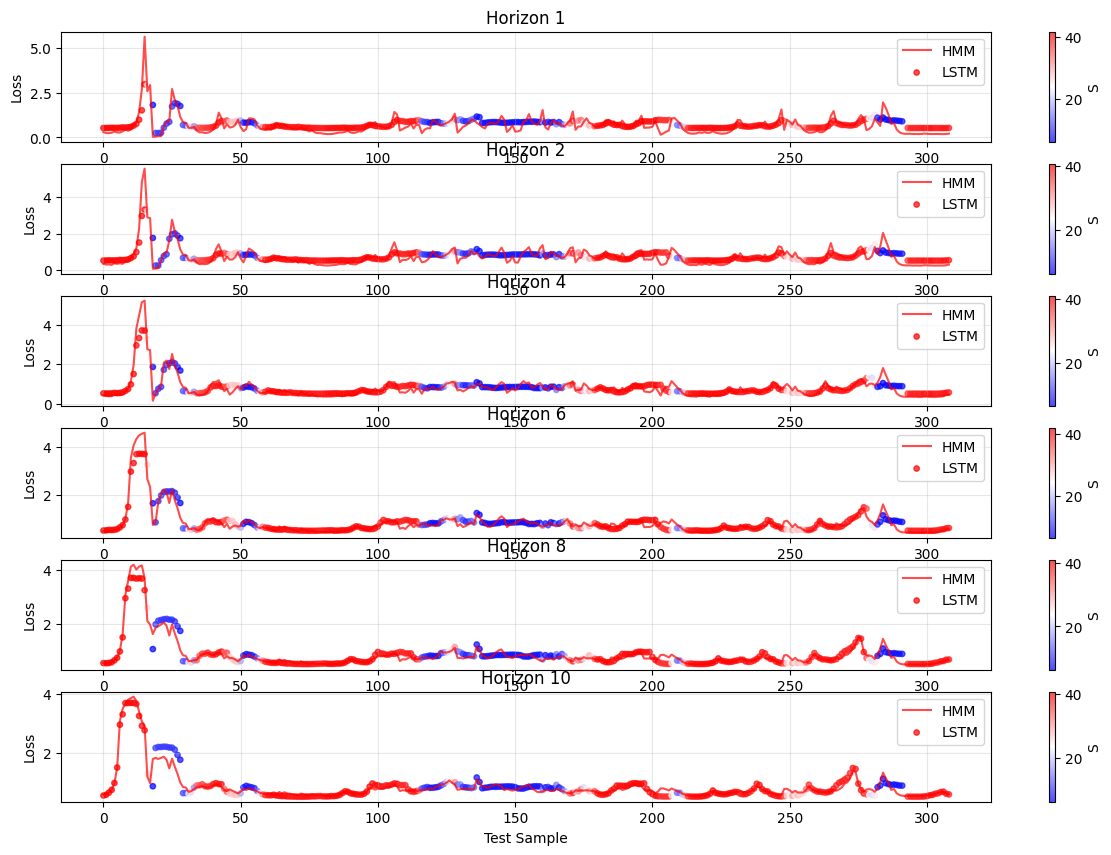

In [56]:
# Horizon indices (0-based): 0, 1, 3
horizons = [0, 1, 3, 5, 7, 9]
titles = ['Horizon 1', 'Horizon 2', 'Horizon 4', 'Horizon 6', 'Horizon 8', 'Horizon 10']

plt.figure(figsize=(15, 10))

for i, horizon in enumerate(horizons):
    ax = plt.subplot(len(horizons), 1, i + 1)
    ax.plot(hmm_state_losses[:, horizon], label='HMM', color='red', alpha=0.7)
    sc = ax.scatter(
        x=range(len(loss_test[:, horizon])),
        y=loss_test[:, horizon],
        c=(S_test[:, horizon]),   # color by S_reshaped values
        cmap='bwr',
        alpha=0.7,
        s=15,
        label='LSTM'
    )
    plt.colorbar(sc, ax=ax, label='S')
    ax.set_title(titles[i])
    ax.set_xlabel('Test Sample')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

In [57]:
# Correlation between uncertainty mass (S_reshaped) and loss (loss_reshaped)
loss_diff = hmm_state_losses - loss_test # Element-wise difference

# Overall (all horizons pooled)
overall_pearson = np.corrcoef(S_test.ravel(), loss_diff.ravel())[0, 1]

# Per-horizon Pearson correlation
corr_by_horizon = [
    np.corrcoef(S_test[:, h].ravel(), loss_diff[:, h].ravel())[0, 1]
    for h in range(forecast_horizon)
]

corr_df = pd.DataFrame({
    "horizon": np.arange(1, forecast_horizon + 1),
    "pearson_corr_S_vs_loss": corr_by_horizon
})

print(f"Overall Pearson correlation (S vs loss): {overall_pearson:.4f}")
corr_df

Overall Pearson correlation (S vs loss): 0.0741


,horizon,pearson_corr_S_vs_loss
0,1,0.035191
1,2,0.011010
2,3,0.026288
3,4,0.015524
4,5,0.054159
5,6,0.102324
6,7,0.160787
7,8,0.174546
8,9,0.206698
9,10,0.244701


In [58]:
horizon = S_test.copy()
# Fill each column with its 1-based horizon index (vectorized, no loop)
horizon[:] = np.arange(1, horizon.shape[1] + 1)


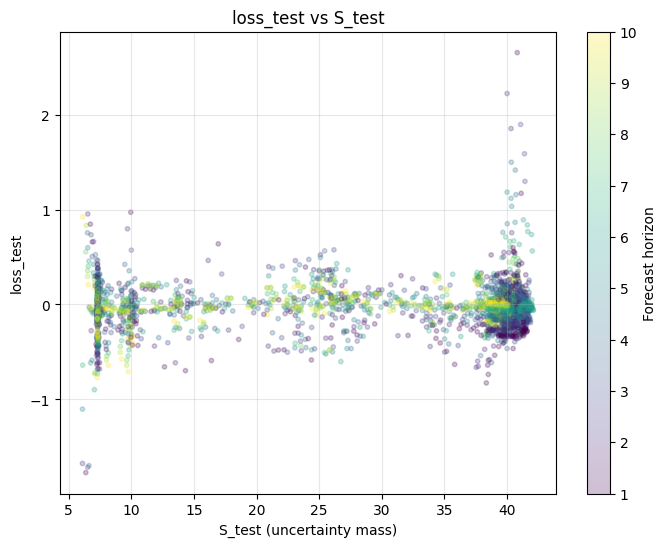

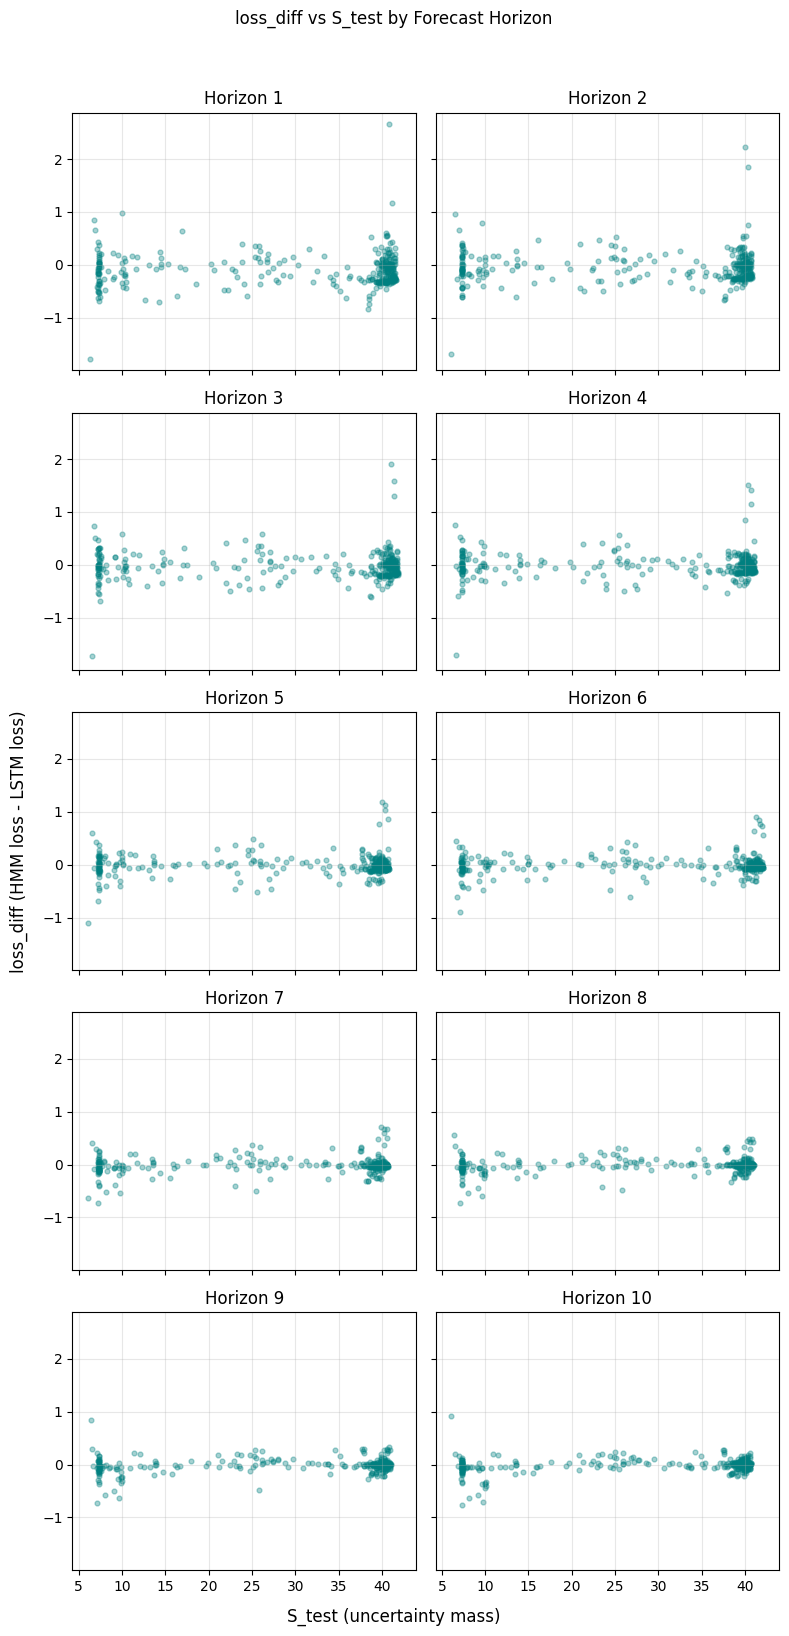

In [59]:
# Scatter plot of loss_test vs S_test (all horizons pooled)
plt.figure(figsize=(8, 6))
sc = plt.scatter(
    S_test.ravel(),
    loss_diff.ravel(),
    alpha=0.25,
    s=10,
    c=horizon.ravel(),      # use c= for numeric colormapping
    cmap='viridis'
)
plt.colorbar(sc, label='Forecast horizon')
plt.xlabel('S_test (uncertainty mass)')
plt.ylabel('loss_test')
plt.title('loss_test vs S_test')
plt.grid(True, alpha=0.3)

# Subplots: loss_diff vs S_test for each horizon
n_cols = 2
n_rows = int(np.ceil(forecast_horizon / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.2 * n_rows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

for h in range(forecast_horizon):
    ax = axes[h]
    ax.scatter(S_test[:, h], loss_diff[:, h], alpha=0.35, s=12, color='teal')
    ax.set_title(f'Horizon {h + 1}')
    ax.grid(True, alpha=0.3)

# Hide any unused axes
for ax in axes[forecast_horizon:]:
    ax.axis('off')

fig.supxlabel('S_test (uncertainty mass)')
fig.supylabel('loss_diff (HMM loss - LSTM loss)')
fig.suptitle('loss_diff vs S_test by Forecast Horizon', y=1.02)
plt.tight_layout()
plt.show()

## Hybrid Model

In [60]:
transition_matrix = hmm_transition_matrix.drop(columns=['Unnamed: 0'])
transition_matrix = transition_matrix.rename(columns={'state.1.1': 0, 'state.2.1': 1, 'state.3.1': 2})

alpha = 0.3
def hybrid_model(probs_reshaped, S_reshaped, transition_matrix, alpha_0, alpha_1, last_state, Y_reshaped):

    S_scaled = (S_reshaped - np.min(S_reshaped)) / (np.max(S_reshaped) - np.min(S_reshaped))
    alpha = alpha_0 + alpha_1 * S_scaled
    alpha = np.clip(alpha, 0.0, 1.0)

    trials = probs_reshaped.shape[0]
    horizons = probs_reshaped.shape[1]
    combined_transitions = np.zeros((trials, horizons, n_states, n_states))
    for trial in range(trials):
        for horizon in range(horizons):
            #_alpha = (alpha + 0) / (horizon + 0 + 1)
            _alpha = alpha[trial, horizon]
            combined = np.tile(probs_reshaped[trial, horizon, :], (n_states, 1)) * _alpha + transition_matrix * (1 - _alpha)
            combined_transitions[trial, horizon, :, :] = combined

    hybrid_predictions = np.zeros((trials, horizons, n_states))
    for trial in range(trials):
        for horizon in range(horizons):
            if horizon == 0:
                last_prediction = last_state[trial, :]
            else:
                last_prediction = hybrid_predictions[trial, horizon - 1, :]
            next_prediction = last_prediction @ combined_transitions[trial, horizon, :, :]
            hybrid_predictions[trial, horizon, :] = next_prediction

    eps = 1e-15
    hybrid_state_loss = -np.sum(
        Y_reshaped * np.log(np.clip(hybrid_predictions, eps, 1.0)),
        axis=2
    )

    return hybrid_predictions, hybrid_state_loss

Find the optimal alpha parameter using the validation set.

In [61]:
n_0 = 15
n_1 = 20
min_alpha_0 = 0
max_alpha_0 = 0.15
min_alpha_1 = 0
max_alpha_1 = 0.2
valid = False
alpha_stats = {'alpha_0': np.zeros((n_0,n_1)), 'alpha_1': np.zeros((n_0,n_1)), 'min_loss': np.zeros((n_0,n_1)), 
               '25 percentile': np.zeros((n_0,n_1)), 'mean_loss': np.zeros((n_0,n_1)), 
               '75 percentile': np.zeros((n_0,n_1)), 'max_loss': np.zeros((n_0,n_1))}
for i, alpha_0 in enumerate(np.linspace(min_alpha_0, max_alpha_0, n_0)):
    for j, alpha_1 in enumerate(np.linspace(min_alpha_1, max_alpha_1, n_1)):
        if valid:
            probs = probs_valid
            S = S_valid
            last_state = last_state_valid
            Y_reshaped = Y_valid_reshaped
        else:
            probs = probs_test
            S = S_test
            last_state = last_state_test
            Y_reshaped = Y_test_reshaped
        predictions, loss = hybrid_model(
            probs, S,
            transition_matrix,
            alpha_0, alpha_1, 
            last_state, 
            Y_reshaped)
        alpha_stats['alpha_0'][i, j] = alpha_0
        alpha_stats['alpha_1'][i, j] = alpha_1
        alpha_stats['min_loss'][i, j] = np.min(loss)
        alpha_stats['25 percentile'][i, j] = np.percentile(loss, 25)
        alpha_stats['mean_loss'][i, j] = np.mean(loss)
        alpha_stats['75 percentile'][i, j] = np.percentile(loss, 75)
        alpha_stats['max_loss'][i, j] = np.max(loss)   


In [62]:
min_idx = np.unravel_index(np.argmin(alpha_stats['mean_loss']), alpha_stats['mean_loss'].shape)
min_idx

(np.int64(4), np.int64(8))

$$ \alpha = \alpha_0 + S*\alpha_1$$

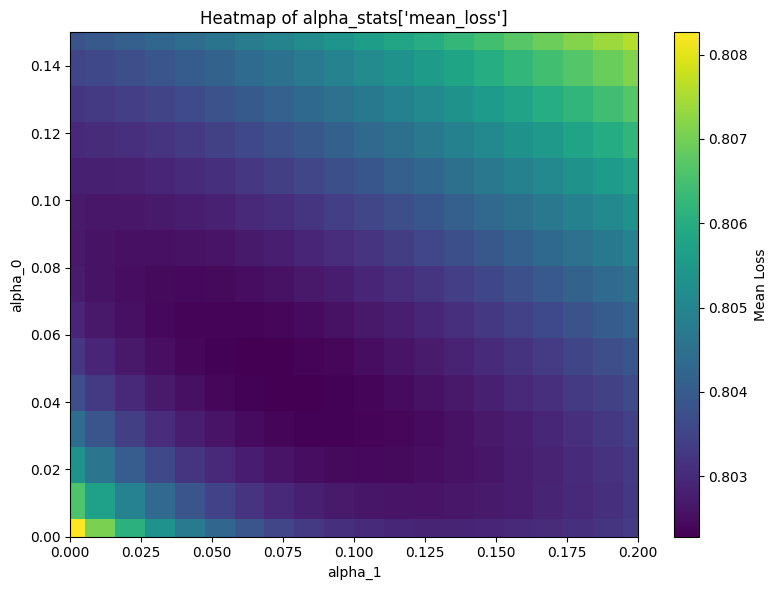

In [63]:
alpha_0_vals = np.linspace(min_alpha_0, max_alpha_0, n_0)
alpha_1_vals = np.linspace(min_alpha_1, max_alpha_1, n_1)

plt.figure(figsize=(8, 6))
pcm = plt.pcolormesh(
    alpha_1_vals,
    alpha_0_vals,
    alpha_stats['mean_loss'],
    shading='auto',
    cmap='viridis'
)
plt.colorbar(pcm, label='Mean Loss')

plt.title("Heatmap of alpha_stats['mean_loss']")
plt.xlabel('alpha_1')
plt.ylabel('alpha_0')
plt.xlim(alpha_1_vals.min(), alpha_1_vals.max())
plt.ylim(alpha_0_vals.min(), alpha_0_vals.max())
# plt.axvline(x=0, color='red', linestyle='-', linewidth=1.5)
# plt.axhline(y=0, color='red', linestyle='-', linewidth=1.5)

plt.tight_layout()
plt.show()

In [64]:
# Compute statistics for each column of lstm_state_losses
hybrid_predictions_test, hybrid_loss_test = hybrid_model(
    probs_reshaped=probs_test,
    S_reshaped=S_test,
    transition_matrix=transition_matrix, 
    alpha_0=0, 
    alpha_1=0.1, 
    last_state=last_state_test, 
    Y_reshaped=Y_test_reshaped)
hybrid_loss_df = pd.DataFrame({
    'mean': np.nanmean(hybrid_loss_test, axis=0),
    'median': np.nanmedian(hybrid_loss_test, axis=0),
    'P25': np.nanpercentile(hybrid_loss_test, 25, axis=0),
    'P75': np.nanpercentile(hybrid_loss_test, 75, axis=0),
    'max': np.nanmax(hybrid_loss_test, axis=0),
    'min': np.nanmin(hybrid_loss_test, axis=0)
})
hybrid_loss_df

,mean,median,P25,P75,max,min
0,0.654322,0.590797,0.342428,0.804391,4.671126,0.040524
1,0.723276,0.649289,0.427219,0.836031,4.543126,0.083613
2,0.770275,0.694074,0.488106,0.866521,4.644261,0.126351
3,0.801891,0.714411,0.546237,0.887620,4.357442,0.172929
4,0.824153,0.728428,0.583658,0.868901,4.140465,0.430972
5,0.837837,0.733485,0.606764,0.860477,3.975326,0.466597
6,0.847669,0.734787,0.624205,0.844415,3.845760,0.498459
7,0.855455,0.729537,0.633843,0.844622,3.742520,0.527017
8,0.857394,0.728637,0.640156,0.839466,3.655016,0.547979
9,0.858261,0.726346,0.645772,0.849326,3.581752,0.565839


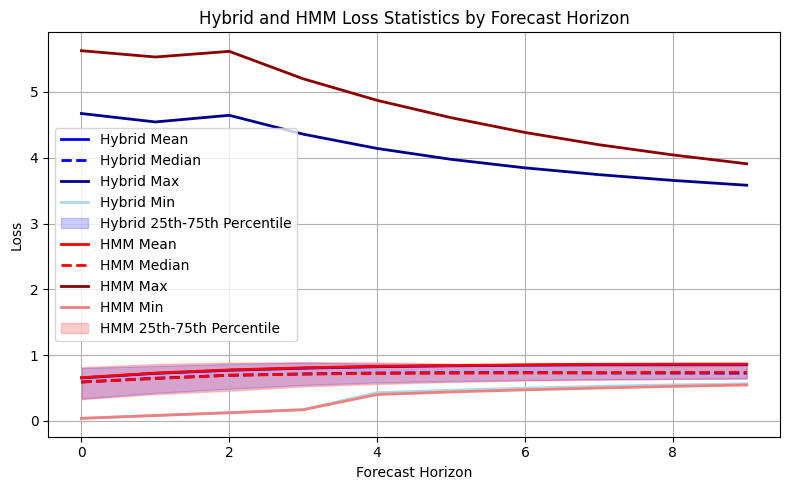

In [65]:
plot_model_comparison(hybrid_loss_df, hmm_stats_df, 'Hybrid', 'HMM')

In [66]:
start_date = pd.to_datetime("2020-01-01")
date_list = pd.date_range(start=start_date, periods=len(loss_test), freq="W").date.tolist()

date_list[:5], date_list[-1]

([datetime.date(2020, 1, 5),
  datetime.date(2020, 1, 12),
  datetime.date(2020, 1, 19),
  datetime.date(2020, 1, 26),
  datetime.date(2020, 2, 2)],
 datetime.date(2025, 11, 30))

/tmp/ipykernel_1541166/1569386054.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


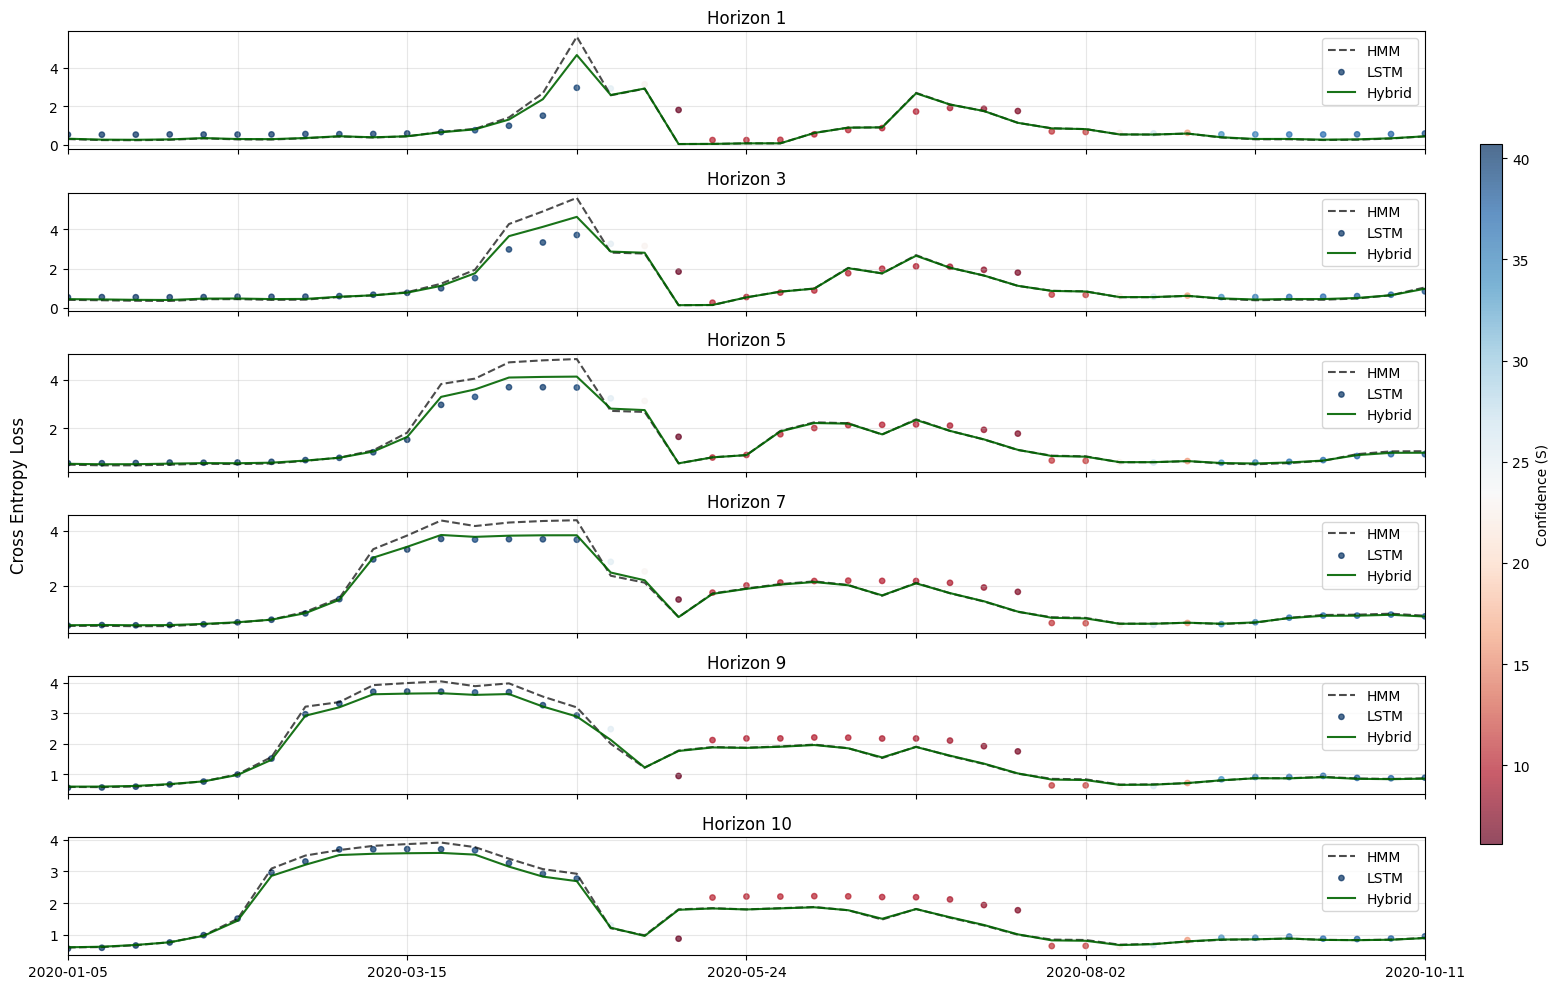

In [67]:
plt.figure(figsize=(15, 10))

horizons = [0, 2, 4, 6, 8, 9]
titles = ['Horizon 1', 'Horizon 3', 'Horizon 5', 'Horizon 7', 'Horizon 9', 'Horizon 10']
xlimits = [0, 40]

for i, horizon in enumerate(horizons):
    ax = plt.subplot(len(horizons), 1, i + 1)
    ax.plot(hmm_state_losses[:, horizon], label='HMM', color='black', linestyle='--', alpha=0.7)
    sc = ax.scatter(
        x=range(len(loss_test[:, horizon])),
        y=loss_test[:, horizon],
        c=(S_test[:, horizon]),   # color by S_reshaped values
        cmap='RdBu',
        alpha=0.7,
        s=15,
        label='LSTM'
    )
    #plt.colorbar(sc, ax=ax, label='Confidence (S)')
    ax.plot(hybrid_loss_test[:, horizon], label='Hybrid', color='darkgreen', alpha=0.9)
    ax.set_title(titles[i])
    if i == 0:
        plt.gcf().supylabel('Cross Entropy Loss')
    ax.set_yscale('linear')
    ax.set_xticklabels([])
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(xlimits[0], xlimits[1])
    #ax.set_ylim(0, 6)
    if i == len(horizons) - 1:
        tick_idx = np.arange(0, min(len(date_list), xlimits[1] + 1), 10)
        ax.set_xticks(tick_idx)
        ax.set_xticklabels([date_list[k].strftime("%Y-%m-%d") for k in tick_idx], rotation=0, ha='center')

fig = plt.gcf()
fig.subplots_adjust(right=0.88)  # leave room for colorbar on the right

if 'sc' in locals():
    cax = fig.add_axes([1, 0.15, 0.015, 0.7])  # [left, bottom, width, height]
    fig.colorbar(sc, cax=cax, label='Confidence (S)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1541166/1569386054.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


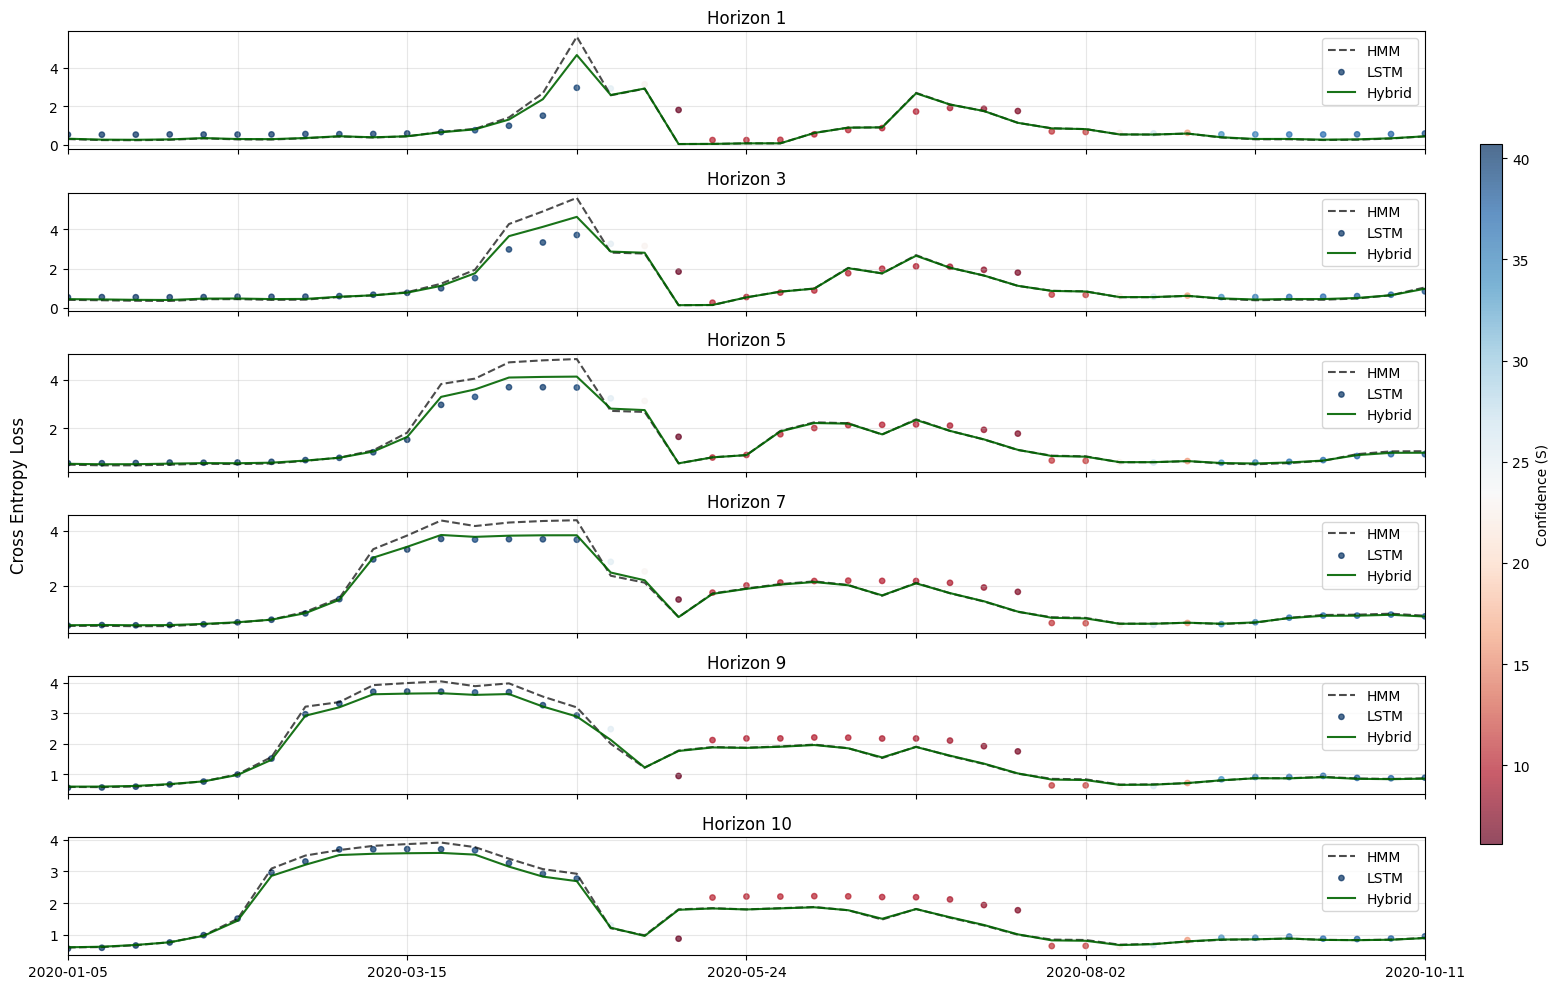

In [68]:
plt.figure(figsize=(15, 10))

horizons = [0, 2, 4, 6, 8, 9]
titles = ['Horizon 1', 'Horizon 3', 'Horizon 5', 'Horizon 7', 'Horizon 9', 'Horizon 10']
xlimits = [0, 40]

for i, horizon in enumerate(horizons):
    ax = plt.subplot(len(horizons), 1, i + 1)
    ax.plot(hmm_state_losses[:, horizon], label='HMM', color='black', linestyle='--', alpha=0.7)
    sc = ax.scatter(
        x=range(len(loss_test[:, horizon])),
        y=loss_test[:, horizon],
        c=(S_test[:, horizon]),   # color by S_reshaped values
        cmap='RdBu',
        alpha=0.7,
        s=15,
        label='LSTM'
    )
    #plt.colorbar(sc, ax=ax, label='Confidence (S)')
    ax.plot(hybrid_loss_test[:, horizon], label='Hybrid', color='darkgreen', alpha=0.9)
    ax.set_title(titles[i])
    if i == 0:
        plt.gcf().supylabel('Cross Entropy Loss')
    ax.set_yscale('linear')
    ax.set_xticklabels([])
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(xlimits[0], xlimits[1])
    #ax.set_ylim(0, 6)
    if i == len(horizons) - 1:
        tick_idx = np.arange(0, min(len(date_list), xlimits[1] + 1), 10)
        ax.set_xticks(tick_idx)
        ax.set_xticklabels([date_list[k].strftime("%Y-%m-%d") for k in tick_idx], rotation=0, ha='center')

fig = plt.gcf()
fig.subplots_adjust(right=0.88)  # leave room for colorbar on the right

if 'sc' in locals():
    cax = fig.add_axes([1, 0.15, 0.015, 0.7])  # [left, bottom, width, height]
    fig.colorbar(sc, cax=cax, label='Confidence (S)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1541166/569273417.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


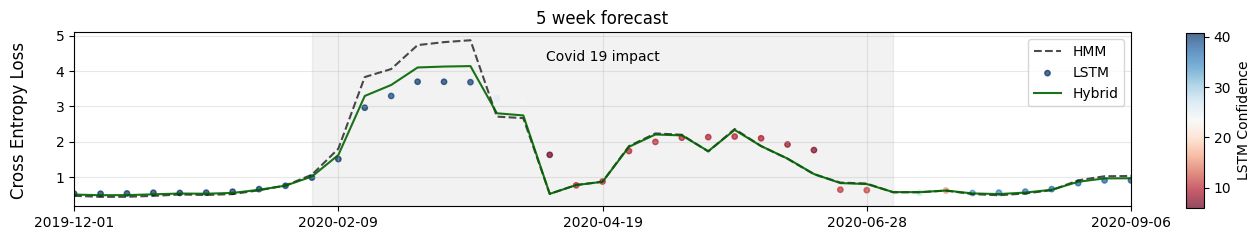

In [69]:
start_date = pd.to_datetime("2019-11-01")
date_list = pd.date_range(start=start_date, periods=len(loss_test), freq="W").date.tolist()


plt.figure(figsize=(12, 2.5))

horizons = [4]
titles = ['5 week forecast']
xlimits = [0, 40]

date_list = date_list[horizons[0]::]

for i, horizon in enumerate(horizons):
    ax = plt.subplot(len(horizons), 1, i + 1)
    ax.plot(hmm_state_losses[:, horizon], label='HMM', color='black', linestyle='--', alpha=0.7)
    sc = ax.scatter(
        x=range(len(loss_test[:, horizon])),
        y=loss_test[:, horizon],
        c=(S_test[:, horizon]),   # color by S_reshaped values
        cmap='RdBu',
        alpha=0.7,
        s=15,
        label='LSTM'
    )
    #plt.colorbar(sc, ax=ax, label='Confidence (S)')
    ax.plot(hybrid_loss_test[:, horizon], label='Hybrid', color='darkgreen', alpha=0.9)
    ax.set_title(titles[i])
    if i == 0:
        plt.gcf().supylabel('Cross Entropy Loss')
    ax.set_yscale('linear')
    ax.set_xticklabels([])
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(xlimits[0], xlimits[1])
    ax.axvspan(9, 31, color='grey', alpha=0.1, zorder=0)
    y_top = ax.get_ylim()[1]
    ax.text(
        (9 + 31) / 2,
        y_top * 0.9,
        'Covid 19 impact',
        ha='center',
        va='top',
        fontsize=10,
        color='black'
    )
    #ax.set_ylim(0, 6)
    if i == len(horizons) - 1:
        tick_idx = np.arange(0, min(len(date_list), xlimits[1] + 1), 10)
        ax.set_xticks(tick_idx)
        ax.set_xticklabels([date_list[k].strftime("%Y-%m-%d") for k in tick_idx], rotation=0, ha='center')

fig = plt.gcf()
fig.subplots_adjust(right=0.88)  # leave room for colorbar on the right

if 'sc' in locals():
    cax = fig.add_axes([1, 0.15, 0.015, 0.7])  # [left, bottom, width, height]
    fig.colorbar(sc, cax=cax, label='LSTM Confidence')
plt.tight_layout()
plt.show()

In [70]:
# KL divergence D_KL(Y_test || prediction) for each sample and timestep

def _to_3d(arr, name):
    arr = np.asarray(arr)
    if arr.ndim == 3:
        return arr
    if arr.ndim == 2 and arr.shape[1] == n_states and arr.shape[0] % forecast_horizon == 0:
        return arr.reshape(forecast_horizon, -1, n_states).transpose(1, 0, 2)
    raise ValueError(f"{name} has incompatible shape: {arr.shape}")

def kl_divergence_per_sample_timestep(y_true, y_pred, eps=1e-12):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)

    # normalize to probability simplex
    y_true = y_true / np.clip(y_true.sum(axis=-1, keepdims=True), eps, None)
    y_pred = y_pred / np.clip(y_pred.sum(axis=-1, keepdims=True), eps, None)

    return np.sum(
        y_true * (np.log(np.clip(y_true, eps, 1.0)) - np.log(np.clip(y_pred, eps, 1.0))),
        axis=-1
    )

Y_true_3d = _to_3d(Y_test_reshaped if "Y_test_reshaped" in globals() else Y_test, "Y_test")
hybrid_3d = _to_3d(hybrid_predictions_test, "hybrid_predictions_test")
lstm_3d = _to_3d(probs_test, "probs_test")
hmm_3d = _to_3d(hmm_predictions, "hmm_predictions")

kl_hybrid = kl_divergence_per_sample_timestep(Y_true_3d, hybrid_3d)  # shape: (samples, horizon)
kl_lstm = kl_divergence_per_sample_timestep(Y_true_3d, lstm_3d)      # shape: (samples, horizon)
kl_hmm = kl_divergence_per_sample_timestep(Y_true_3d, hmm_3d)        # shape: (samples, horizon)

# Optional summary
kl_summary = pd.DataFrame({
    "hybrid_mean": kl_hybrid.mean(axis=0),
    "lstm_mean": kl_lstm.mean(axis=0),
    "hmm_mean": kl_hmm.mean(axis=0),
})
kl_summary

,hybrid_mean,lstm_mean,hmm_mean
0,0.249421,0.353946,0.252610
1,0.318052,0.374369,0.322318
2,0.364276,0.397745,0.369177
3,0.395018,0.412480,0.400224
4,0.416212,0.430003,0.421807
5,0.428598,0.443271,0.433999
6,0.436861,0.453859,0.442210
7,0.443186,0.458646,0.448704
8,0.444414,0.461112,0.450441
9,0.444669,0.464169,0.451333


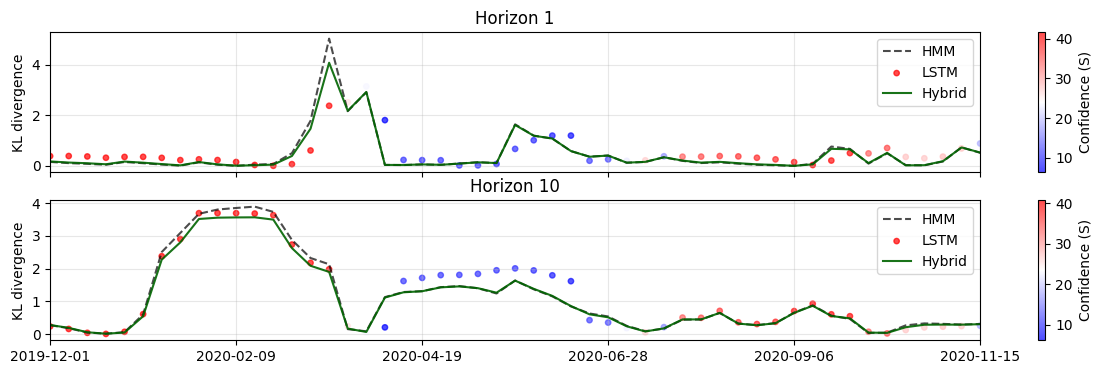

In [71]:
plt.figure(figsize=(15, 4))

horizons = [0, 9]
titles = ['Horizon 1', 'Horizon 10']

for i, horizon in enumerate(horizons):
    ax = plt.subplot(len(horizons), 1, i + 1)
    ax.plot(kl_hmm[:, horizon], label='HMM', color='black', linestyle='--', alpha=0.7)
    sc = ax.scatter(
        x=range(len(kl_lstm[:, horizon])),
        y=kl_lstm[:, horizon],
        c=(S_test[:, horizon]),   # color by S_reshaped values
        cmap='bwr',
        alpha=0.7,
        s=15,
        label='LSTM'
    )
    plt.colorbar(sc, ax=ax, label='Confidence (S)')
    ax.plot(kl_hybrid[:, horizon], label='Hybrid', color='darkgreen', alpha=0.9)
    ax.set_title(titles[i])
    ax.set_ylabel('KL divergence')
    ax.set_yscale('linear')
    ax.set_xticklabels([])
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 50)
    if i == len(horizons) - 1:
        tick_idx = np.arange(0, min(len(date_list), 51), 10)
        ax.set_xticks(tick_idx)
        ax.set_xticklabels([date_list[k].strftime("%Y-%m-%d") for k in tick_idx], rotation=0, ha='center')